In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import joblib

SEED = 42

In [2]:
params_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 10, 15],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [1, 2],
    'rf__max_features': ['sqrt', 'log2']
}

In [3]:
fighting_df = pd.read_csv('../../Data/Processed/selected_fighting_features.csv')

print(fighting_df.shape)

(130, 11)


In [4]:
fighting_X = fighting_df.drop('feedback', axis=1)
fighting_y = fighting_df['feedback']

X_train, X_test, y_train, y_test = train_test_split(fighting_X, fighting_y, test_size=0.2, random_state=SEED, stratify=fighting_y)

pipeline = Pipeline([('scaler', StandardScaler()), ('rf', RandomForestClassifier(random_state=SEED))])

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=params_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

best_parameters = grid_search.best_params_

print(best_parameters.items())

best_fighting_model = grid_search.best_estimator_

y_train_pred = best_fighting_model.predict(X_train)
y_test_pred = best_fighting_model.predict(X_test)

train_score = f1_score(y_train, y_train_pred, average = 'macro')
test_score = f1_score(y_test, y_test_pred, average = 'macro')

print(f"Training f1-score: {train_score}")
print(f"Test f1-score: {test_score}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
dict_items([('rf__max_depth', None), ('rf__max_features', 'sqrt'), ('rf__min_samples_leaf', 1), ('rf__min_samples_split', 2), ('rf__n_estimators', 100)])
Training f1-score: 1.0
Test f1-score: 0.9670588235294119


In [5]:
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

cv_scores = cross_val_score(best_fighting_model, fighting_X, fighting_y, cv=cv, scoring='f1_macro')
print(f"CV Mean: {cv_scores.mean():.3f}")
print(f"CV Std: {cv_scores.std():.3f}")
print(f"All folds: {cv_scores}")

CV Mean: 0.911
CV Std: 0.013
All folds: [0.92231135 0.92185008 0.91764133 0.90555556 0.8880303 ]


In [6]:
final_fighting_pipeline =  Pipeline([('scaler', StandardScaler()), ('rf', RandomForestClassifier(random_state=SEED))])

final_fighting_pipeline.set_params(**best_parameters)

final_fighting_pipeline.fit(fighting_X, fighting_y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [7]:
# Check feature importances
fighting_XAI = final_fighting_pipeline.named_steps['rf']
fighting_importances = fighting_XAI.feature_importances_
fighting_feature_names = fighting_X.columns
for name, imp in sorted(zip(fighting_feature_names, fighting_importances), key=lambda x: x[1], reverse=True):
    print(f"{name}: {imp:.3f}")

combatEfficiency: 0.332
damageIntakeRate: 0.172
damagePerSecond: 0.139
combatPerformanceIndex: 0.120
comboRate: 0.074
victory: 0.041
playerAccuracy: 0.038
sessionDuration: 0.031
dodgeRate: 0.030
reactionScore: 0.024


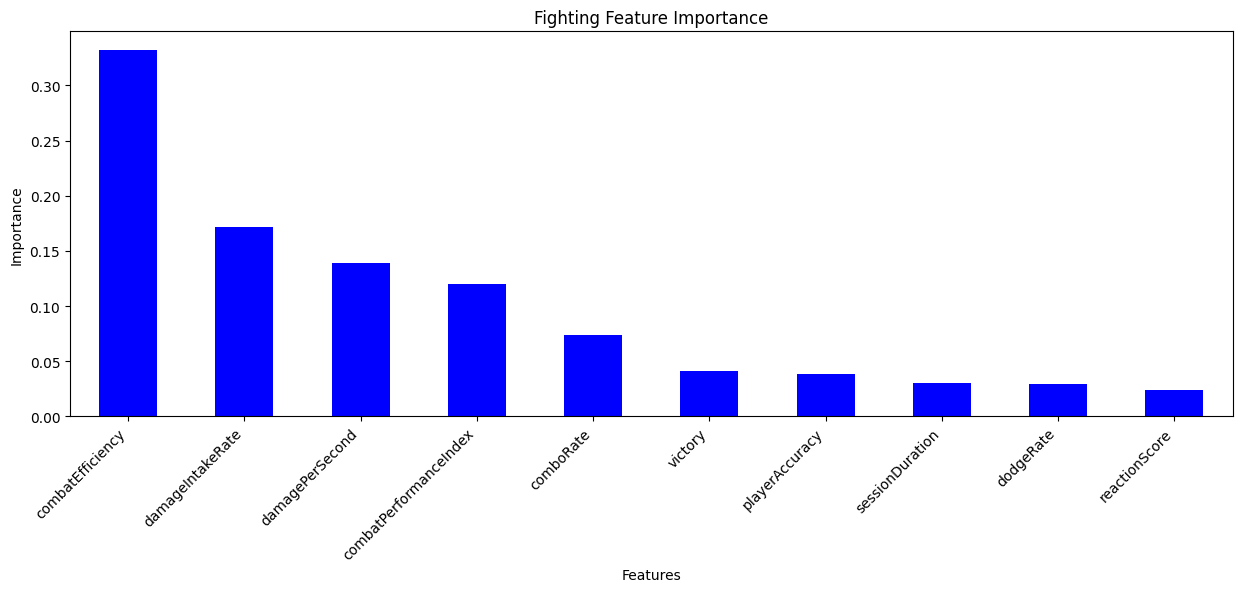

In [8]:
fighting_importance_series = pd.Series(fighting_importances, index=fighting_feature_names)
sorted_fighting_importance = fighting_importance_series.sort_values(ascending=False)

plt.figure(figsize=(15,5))
sorted_fighting_importance.plot(kind='bar', color='blue')
plt.title("Fighting Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
plt.show()

In [9]:
racing_df = pd.read_csv('../../Data/Processed/selected_racing_features.csv')

print(racing_df.shape)

(80, 9)


In [10]:
racing_X = racing_df.drop('feedback', axis=1)
racing_y = racing_df['feedback']

X_train, X_test, y_train, y_test = train_test_split(racing_X, racing_y, test_size=0.2, random_state=SEED, stratify=racing_y)

pipeline = Pipeline([('scaler', StandardScaler()), ('rf', RandomForestClassifier(random_state=SEED))])

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=params_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

best_racing_model = grid_search.best_estimator_

y_train_pred = best_racing_model.predict(X_train)
y_test_pred = best_racing_model.predict(X_test)

train_score = f1_score(y_train, y_train_pred, average='macro')
test_score = f1_score(y_test, y_test_pred, average='macro')

print(f"Training f1-score: {train_score}")
print(f"Testing f1-score: {test_score}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits


c:\Users\Admin\Documents\FYP - Metaverse for Virtual Game\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Training f1-score: 0.9399881164587048
Testing f1-score: 0.9440559440559441


In [11]:
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

cv_scores = cross_val_score(best_racing_model, racing_X, racing_y, cv=cv, scoring='f1_macro')
print(f"CV Mean: {cv_scores.mean():.3f}")
print(f"CV Std: {cv_scores.std():.3f}")
print(f"All folds: {cv_scores}")

CV Mean: 0.900
CV Std: 0.060
All folds: [0.87710438 0.94405594 0.79191919 0.94405594 0.94405594]


In [12]:
best_params = grid_search.best_params_

final_racing_pipeline = Pipeline([('scaler', StandardScaler()), ('rf', RandomForestClassifier(random_state=SEED))])

final_racing_pipeline.set_params(**best_params)
final_racing_pipeline.fit(racing_X, racing_y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5


In [13]:
# Check feature importances
racing_XAI = final_racing_pipeline.named_steps['rf']
racing_importances = racing_XAI.feature_importances_
racing_feature_names = racing_X.columns
for name, imp in sorted(zip(racing_feature_names, racing_importances), key=lambda x: x[1], reverse=True):
    print(f"{name}: {imp:.3f}")

drivingSmoothness: 0.316
collisionRate: 0.287
cleanRacingScore: 0.228
racingPerformanceIndex: 0.107
speedEfficiency: 0.035
timeEfficiency: 0.018
consistency: 0.008
lapsCompleted: 0.001


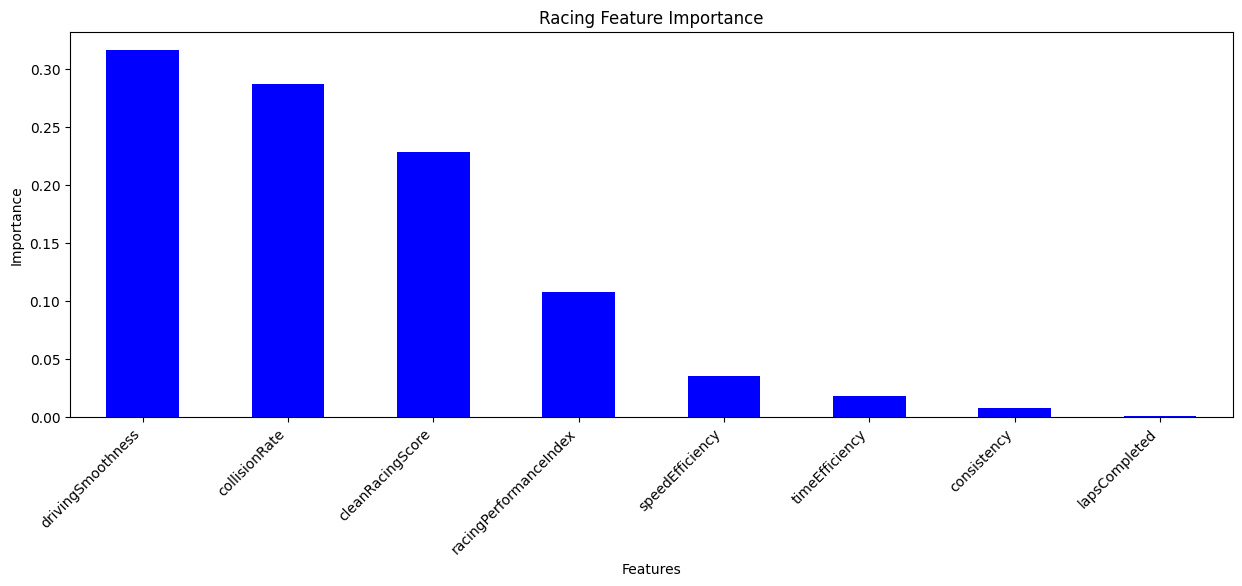

In [14]:
racing_importance_series = pd.Series(racing_importances, index=racing_feature_names)
sorted_racing_importance = racing_importance_series.sort_values(ascending=False)

plt.figure(figsize=(15,5))
sorted_racing_importance.plot(kind='bar', color='blue')
plt.title("Racing Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
plt.show()

In [15]:
joblib.dump(final_fighting_pipeline, r'C:\Users\Admin\Documents\FYP - Metaverse for Virtual Game\Assets\Models\fighting_model.pkl')
joblib.dump(final_racing_pipeline, r'C:\Users\Admin\Documents\FYP - Metaverse for Virtual Game\Assets\Models\racing_model.pkl')

['C:\\Users\\Admin\\Documents\\FYP - Metaverse for Virtual Game\\Assets\\Models\\racing_model.pkl']